In [1]:
import pandas as pd
import pickle as pkl
from sklearn.manifold import TSNE
import torch
import numpy as np

In [2]:
def load_unet_result(path, _print):
    unet_df = pd.read_csv(path, index_col = 'Unnamed: 0')
    index_values = []
    for _index in unet_df.index:
        index_values.append(_index.split('-seg')[0])

    unet_df.index = index_values  
#     unet_df.drop(['WT jaccard', 'TC jaccard', 'ET jaccard'], axis = 1, inplace = True)
    summary_unet_df = pd.DataFrame(zip(unet_df.mean().values.tolist(), 
                                       unet_df.std().values.tolist()), 
                                   columns = ['mean', 'std'], index = unet_df.columns)
    if _print:
        print("****UNet******")
        print(summary_unet_df)
    return summary_unet_df, unet_df

In [3]:
_print = True
path = '../Results/Result/Vanilla_Unet/Unet_test_dice.csv'
summary_unet_df, unet_df = load_unet_result(path, _print)

****UNet******
                mean       std
WT dice     0.888850  0.131130
WT jaccard  0.818860  0.163148
TC dice     0.826315  0.214695
TC jaccard  0.746166  0.235234
ET dice     0.783685  0.208260
ET jaccard  0.680724  0.218424


In [10]:
unet_df[unet_df['WT dice'] > 0.9][0:20]

,WT dice,WT jaccard,TC dice,TC jaccard,ET dice,ET jaccard
BraTS-GLI-00003-000,0.97,0.94,0.95,0.90,0.91,0.83
BraTS-GLI-00005-000,0.95,0.91,0.93,0.88,0.79,0.65
BraTS-GLI-00006-000,0.97,0.95,0.97,0.93,0.91,0.83
BraTS-GLI-00008-001,0.93,0.86,0.86,0.76,0.81,0.68
BraTS-GLI-00011-000,0.94,0.89,0.91,0.84,0.89,0.81
BraTS-GLI-00012-000,0.92,0.85,0.00,0.00,0.02,0.01
BraTS-GLI-00016-001,0.94,0.90,0.95,0.91,0.87,0.77
BraTS-GLI-00017-000,0.94,0.88,0.08,0.04,0.40,0.25
BraTS-GLI-00017-001,0.92,0.85,0.00,0.00,0.00,0.00
BraTS-GLI-00018-000,0.94,0.88,0.64,0.47,0.55,0.38


In [12]:
unet_df[unet_df['WT dice'] < 0.8][0:10]

,WT dice,WT jaccard,TC dice,TC jaccard,ET dice,ET jaccard
BraTS-GLI-00002-000,0.71,0.55,0.62,0.45,0.61,0.44
BraTS-GLI-00008-000,0.63,0.46,0.63,0.46,0.66,0.49
BraTS-GLI-00014-000,0.69,0.52,0.67,0.50,0.64,0.47
BraTS-GLI-00021-000,0.67,0.50,0.16,0.09,0.07,0.04
BraTS-GLI-00028-000,0.78,0.63,0.26,0.15,0.20,0.11
BraTS-GLI-00031-001,0.63,0.46,0.46,0.30,0.41,0.26
BraTS-GLI-00058-000,0.73,0.58,0.94,0.89,0.91,0.83
BraTS-GLI-00072-001,0.65,0.48,0.94,0.88,0.94,0.90
BraTS-GLI-00098-000,0.55,0.38,0.49,0.33,0.31,0.19
BraTS-GLI-00185-000,0.72,0.56,0.76,0.61,0.79,0.65


In [7]:
path = '../Results/Analysis_Results/t-sne/Enc4_numpy.pkl'
Enc_features = torch.load(path, map_location=torch.device('cpu'))

FileNotFoundError: [Errno 2] No such file or directory: '../Results/Analysis_Results/t-sne/Enc4_numpy.pkl'

In [324]:
with open('../Results/Analysis_Results/t-sne/Enc2_numpy.pkl', 'rb') as f:
    Enc_features = pkl.load(f)

In [307]:
all_features = []
all_labels = []
count = 0
for p_id in Enc_features.keys():
    if (unet_df.loc[p_id, 'WT dice'] <.98):
        continue
    features = Enc_features[p_id]['feature']
    mask_resized = Enc_features[p_id]['resized_mask']
    
    features_flattened = features.view(192, -1).T  # Shape: [num_voxels, 192]
    mask_flat = mask_resized.view(-1)

#     tumor_features = features_flattened[mask_flat != 0]
#     tumor_labels = mask_flat[mask_flat != 0]
    
    # Label as 'tumor' (1) and 'non-tumor' (0)
    labels = (mask_flat != 0).long()  # Convert to 0 and 1
    
    # Append to the aggregated lists
    all_features.append(features_flattened)
    all_labels.append(labels)
    count += 2
    if count > 4:
        break
len(all_features)

3

In [308]:
# Concatenate all features and labels
all_features_combined = torch.cat(all_features, dim=0)
all_labels_combined = torch.cat(all_labels, dim=0)
all_features_combined.shape

torch.Size([6075, 192])

In [309]:
features_numpy = all_features_combined.numpy()
labels_numpy = all_labels_combined.numpy()

In [331]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=50, n_iter=5000, learning_rate='auto', init='pca')
tsne_results = tsne.fit_transform(features_numpy)

/Users/suvodeepmajumder/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:982: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


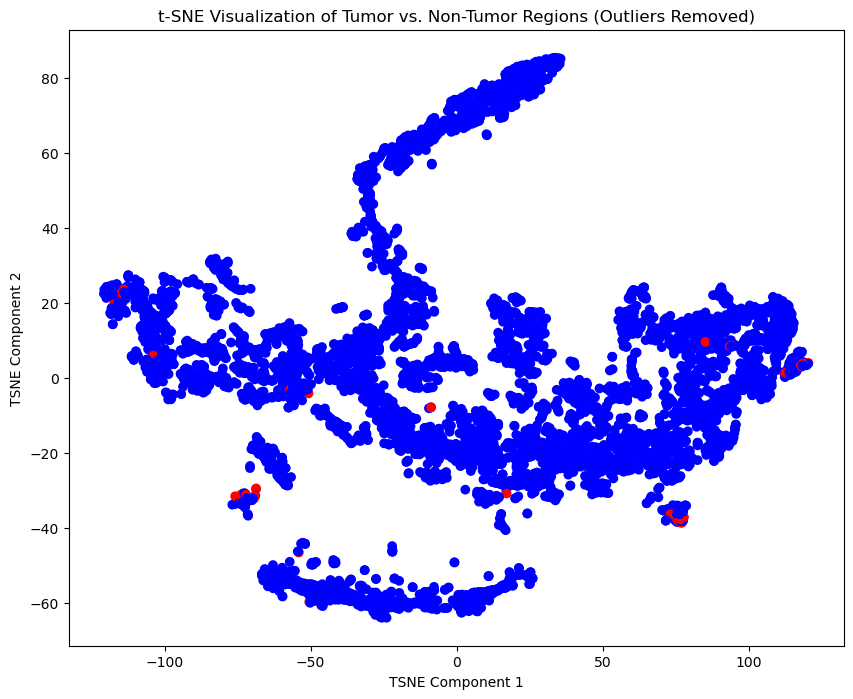

In [332]:
colors = ['red' if label == 1 else 'blue' for label in labels_numpy]
# Plotting without outliers
plt.figure(figsize=(10, 8))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=colors)
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.title('t-SNE Visualization of Tumor vs. Non-Tumor Regions (Outliers Removed)')
plt.show()